# Temporal Context Depth and Readout in EvolveGCN-H for $\Omega_m$ Regression
## CAMELS-SIMBA · U1000 · Top1500 · matched 700/99/201 splits · seeds 42/123/2025

This analysis-only notebook closes the predeclared temporal experimental phase. Part I audits nested temporal context T1–T5 with mean pooling. Part II audits the matched mean-versus-last readout diagnostic at T2 and T5. Static GCN appears only as an external architectural reference. Every value, table, and figure is derived from saved artifacts; no model is trained.


# 1 — Scientific questions and boundaries

The primary diagnostic is \(\Delta_{\rm pool}(T)=\mathrm{MAE}_{last}(T)-\mathrm{MAE}_{mean}(T)\): negative favors last. The descriptive depth × pooling quantity is \(I=\Delta_{\rm pool}(T5)-\Delta_{\rm pool}(T2)\). These are descriptive three-seed comparisons, not inferential tests. “Lowest observed” refers only to the seven predeclared EvolveGCN-H configurations.

Even if last improves T5, pooling cannot be declared the sole cause because depth also changes recurrent evolution, catalogue composition, irregular temporal spacing, and independently selected halo populations.


# 2 — Integrity and fairness gate

Both official verifiers are rerun. The notebook then independently checks family completeness, SHA-256 identities, ordered splits and truths, all prediction rows and stored errors, MSE/RMSE/MAE/\(R^2\)/counts, checkpoint selection, model schemas, parameters, and mean–last configuration equality after excluding only `temporal_pooling`.


In [1]:
from pathlib import Path
from IPython.display import display, Markdown
import subprocess,json,hashlib,math
import numpy as np,pandas as pd,matplotlib.pyplot as plt,torch
ROOT=Path.cwd().resolve()
while ROOT!=ROOT.parent and not (ROOT/"scripts/verify_u1000_top1500_temporal_context_ablation.py").is_file(): ROOT=ROOT.parent
assert (ROOT/"scripts/verify_u1000_top1500_temporal_context_ablation.py").is_file()
OUT=ROOT/"notebooks/visualization/outputs/14_u1000_temporal_context_and_pooling_analysis"; OUT.mkdir(parents=True,exist_ok=True)
for pat in ("fig*.png","table*.csv"):
    for p in OUT.glob(pat): p.unlink()
SEEDS=[42,123,2025]; SNAP=[.2,.25,.51209,.75065,1.]; SUB={T:list(range(5-T,5)) for T in range(1,6)}
COUNTS={"train":700,"val":99,"test":201}; DSHA="ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23c27fbfa4e2f5cdb113"
PARAMS=3408097; TOL=1e-12; C={"mean":"#2F6690","last":"#D1495B"}; SC={42:"#1b9e77",123:"#d95f02",2025:"#7570b3"}
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"font.size":10,"figure.constrained_layout.use":True})
pd.set_option("display.float_format",lambda x:f"{x:.8f}")
def js(p): return json.loads(Path(p).read_text())
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def met(f):
 y=f.true_omega_m.to_numpy(float); p=f.pred_omega_m.to_numpy(float); r=p-y; mse=np.mean(r*r)
 return dict(mse=mse,rmse=np.sqrt(mse),mae=np.mean(abs(r)),r2=1-np.sum(r*r)/np.sum((y-y.mean())**2),num_samples=len(f))
def dia(f):
 y=f.true_omega_m.to_numpy(float); p=f.pred_omega_m.to_numpy(float); r=p-y; q1,q3=np.quantile(y,[.25,.75])
 sl,it=np.polyfit(y,p,1); rsl,rit=np.polyfit(y,r,1); ts=y.std(ddof=1); ps=p.std(ddof=1)
 return dict(bias=r.mean(),true_sd=ts,pred_sd=ps,spread_ratio=ps/ts,prediction_slope=sl,prediction_intercept=it,
  residual_slope=rsl,residual_intercept=rit,residual_mean=r.mean(),low_quartile_residual=r[y<=q1].mean(),high_quartile_residual=r[y>=q3].mean())
def ms(x):
 a=np.asarray(x,float); return f"{a.mean():.9f} ± {a.std(ddof=1):.9f}"
def tab(df,n,name): df.to_csv(OUT/f"table{n:02d}_{name}.csv",index=False); return df
def figsave(fig,n,name): fig.savefig(OUT/f"fig{n:02d}_{name}.png",bbox_inches="tight"); plt.show()
branch=subprocess.run(["git","branch","--show-current"],cwd=ROOT,text=True,capture_output=True,check=True).stdout.strip()
head=subprocess.run(["git","rev-parse","HEAD"],cwd=ROOT,text=True,capture_output=True,check=True).stdout.strip()
commands=[
 [str(ROOT/"envs/camels-gnn/bin/python"),"scripts/verify_u1000_top1500_temporal_context_ablation.py","--require-complete"],
 [str(ROOT/"envs/camels-gnn/bin/python"),"scripts/verify_u1000_top1500_temporal_pooling_diagnostic.py","--require-complete"]]
verdicts=[]
for cmd in commands:
 r=subprocess.run(cmd,cwd=ROOT,text=True,capture_output=True,check=True); print(r.stdout); verdicts.append(r.stdout.strip().splitlines()[-1])
assert verdicts==["FULL 15-CELL VERIFICATION PASS","FULL 12-CELL VERIFICATION PASS"]
dp=js(ROOT/"configs/experiment_families/u1000_top1500_temporal_context_ablation_evolvegcn_h.json")
pp=js(ROOT/"configs/experiment_families/u1000_top1500_temporal_pooling_diagnostic_evolvegcn_h.json")
dataset=ROOT/pp["master_dataset"]["path"]; meta=js(dataset.with_suffix(".metadata.json"))
assert sha(dataset)==DSHA==pp["master_dataset"]["sha256"]; assert (meta["k"],meta["box_size"],meta["num_nodes"],meta["normalization"])==(8,25.,1500,"none")
assert meta["feature_names"]==["log10_Mvir","X","Y","Z","VX","VY","VZ"]
dr={(int(r["T"]),"mean",int(r["seed"])):r for r in dp["runs"]}; pr={(int(r["T"]),r["pooling"],int(r["seed"])):r for r in pp["runs"]}
assert set(dr)=={(T,"mean",s) for T in range(1,6) for s in SEEDS}; assert set(pr)=={(T,p,s) for T in (2,5) for p in ("mean","last") for s in SEEDS}
runs=dict(dr); runs.update({k:v for k,v in pr.items() if k[1]=="last"}); assert len(runs)==21
mans={}
for s in SEEDS:
 r=pr[(2,"mean",s)]; path=ROOT/r["split_manifest_path"]; m=js(path); assert sha(path)==r["split_manifest_sha256"]; assert m["dataset_identity"]==DSHA and m["seed"]==s
 ids=[]
 for split,n in COUNTS.items(): assert len(m[f"{split}_ids"])==n; ids+=m[f"{split}_ids"]
 assert len(set(ids))==1000; mans[s]=m
SK=("model","dataset_path","dataset_identity","seed","batch_size","epochs","patience","learning_rate","weight_decay","hidden_dim","num_layers","dropout","activation","graph_pooling","head_type","add_self_loops","train_ratio","val_ratio","test_ratio","grad_clip_norm","optimizer","loss","scheduler","checkpoint_criterion","normalize_target","use_summary_features","num_total_universes","num_train_universes","num_val_universes","num_test_universes","num_nodes","node_features","trainable_parameters")
def norm(c):
 T=int(c["num_snapshots"])
 return {**{k:c.get(k) for k in SK},"num_snapshots":T,"selected_snapshot_indices":c.get("selected_snapshot_indices",SUB[T]),
  "selected_snapshot_values":c.get("selected_snapshot_values",[SNAP[i] for i in SUB[T]]),"temporal_protocol":c.get("temporal_protocol") or "nested_suffix_context_v1",
  "train_ids":c.get("train_ids"),"val_ids":c.get("val_ids"),"test_ids":c.get("test_ids")}
rr=[]; mr=[]; dg=[]; frames={}; schema0=None; metric_checks=error_checks=0
for (T,pool,s),r in sorted(runs.items()):
 exp=ROOT/r["experiment_path"]; c=js(exp/"config.json"); saved=js(exp/"metrics.json")
 assert c["seed"]==s and c["temporal_pooling"]==pool and int(c["num_snapshots"])==T and c["dataset_identity"]==DSHA and c["trainable_parameters"]==PARAMS
 assert norm(c)["selected_snapshot_indices"]==SUB[T] and np.allclose(norm(c)["selected_snapshot_values"],[SNAP[i] for i in SUB[T]],rtol=0,atol=0)
 cp_path=exp/"checkpoints/best_model.pt"
 try: cp=torch.load(cp_path,map_location="cpu",weights_only=False)
 except TypeError: cp=torch.load(cp_path,map_location="cpu")
 schema=[(k,tuple(v.shape)) for k,v in cp["model_state_dict"].items()]
 if schema0 is None: schema0=schema
 assert schema==schema0 and cp["config"]==c and int(cp["epoch"])==int(saved["best_epoch"])
 log=pd.read_csv(exp/"train_log.csv"); assert math.isclose(float(cp["best_val_mse"]),float(log.val_mse.min()),abs_tol=TOL,rel_tol=0)
 rr.append(dict(T=T,pooling=pool,seed=s,origin="reused" if (T in (2,5) and pool=="mean") else "new",experiment_path=r["experiment_path"],
  snapshot_indices=str(SUB[T]),snapshot_values=str([SNAP[i] for i in SUB[T]]),dataset_path=r["dataset_path"],dataset_sha256=DSHA,
  split_manifest_path=r["split_manifest_path"],split_manifest_sha256=r["split_manifest_sha256"],source_commit=c.get("training_git_commit"),
  checkpoint_sha256=sha(cp_path),best_epoch=int(saved["best_epoch"]),trainable_parameters=c["trainable_parameters"]))
 for split,n in COUNTS.items():
  f=pd.read_csv(exp/f"predictions/{split}_predictions.csv"); assert len(f)==n and f.universe_id.is_unique and f.universe_id.tolist()==mans[s][f"{split}_ids"]
  assert np.isfinite(f[["true_omega_m","pred_omega_m","absolute_error","squared_error"]]).all().all()
  res=f.pred_omega_m.to_numpy()-f.true_omega_m.to_numpy(); assert np.allclose(f.absolute_error,abs(res),atol=TOL,rtol=0) and np.allclose(f.squared_error,res**2,atol=TOL,rtol=0); error_checks+=2*n
  mm=met(f)
  for k in ("mse","rmse","mae","r2"): assert math.isclose(float(saved[split][k]),mm[k],abs_tol=TOL,rel_tol=0); metric_checks+=1
  assert saved[split]["num_samples"]==mm["num_samples"]==n; metric_checks+=1
  mr.append(dict(T=T,pooling=pool,seed=s,split=split,**mm,best_epoch=int(saved["best_epoch"]))); frames[(T,pool,s,split)]=f
  if split=="test": dg.append(dict(T=T,pooling=pool,seed=s,**dia(f)))
pair_mismatch=[]; truth_mismatch=[]
for T in (2,5):
 for s in SEEDS:
  a=js(ROOT/pr[(T,"mean",s)]["experiment_path"]/"config.json"); b=js(ROOT/pr[(T,"last",s)]["experiment_path"]/"config.json")
  if norm(a)!=norm(b): pair_mismatch.append((T,s))
  for split in COUNTS:
   fa,fb=frames[(T,"mean",s,split)],frames[(T,"last",s,split)]
   if list(zip(fa.universe_id,fa.true_omega_m))!=list(zip(fb.universe_id,fb.true_omega_m)): truth_mismatch.append((T,s,split))
assert not pair_mismatch and not truth_mismatch
runs_df=pd.DataFrame(rr); metrics=pd.DataFrame(mr); diag=pd.DataFrame(dg); inventory=runs_df.query("T in [2,5]").copy(); assert len(inventory)==12
display(pd.DataFrame([
 ["Temporal depth","15/15",verdicts[0]],["Pooling diagnostic","12/12",verdicts[1]],["Pooling predictions","36/36","700/99/201 rows"],
 ["Metric reproduction","PASS",f"{12*3*5} pooling comparisons; 0 failures"],["Pair controls","6/6","0 discrepancies; 0 ID/truth mismatches"],
 ["Model invariance","PASS",f"{PARAMS:,} parameters; identical key/shape schema"],["Dataset","PASS",DSHA]],
 columns=["Check","Result","Evidence"]))
print(f"All-temporal metric checks={metric_checks}; stored-error checks={error_checks}; failures=0; branch={branch}; HEAD={head}")


VERIFIED temporal family structure and frozen 5x3 matrix.
Conceptual matrix: 15 cells
Reusable: 3 T5 cells
Runnable/new: 0 T1-T4 cells
Unexpected collisions: 0
Missing required T5 reused cells: 0
Completed cells verified: 15
Real-data audit: {"minimum_real_nodes": 157, "padded_temporal_graph_occurrences": 133, "subset_views": 5000, "temporal_graphs_checked": 15000, "universes": 1000}
T5 provenance: {"T": 5, "checkpoint_sha256": "21d9ffc79bc4f34280eca06de1b4a551b14139b86b63d49c0a91622fcdcba99b", "origin": "reusable_existing", "seed": 42, "source_commit": "eeb4f8cfaba81a6634090fa6064c39d0822a3060", "test_mae": 0.06025855836287067}
T5 provenance: {"T": 5, "checkpoint_sha256": "1c0f9f2ae1214492986d8f43cb51fa1218cdcc47222154384379d7684ca757e1", "origin": "reusable_existing", "seed": 123, "source_commit": "eeb4f8cfaba81a6634090fa6064c39d0822a3060", "test_mae": 0.05098572128744268}
T5 provenance: {"T": 5, "checkpoint_sha256": "ae1a048c9fe77e28737a01424cce5902fc9d997f08cefba75223a5eef23d8ead",

VERIFIED frozen T2/T5 mean-vs-last temporal-pooling diagnostic
Conceptual = 12
Reused mean = 6
New last = 0 missing/runnable; 6 complete
Unexpected collisions = 0
Completed cells verified = 12
Parameter count = 3408097; mean/last state schema identical
FULL 12-CELL VERIFICATION PASS



,Check,Result,Evidence
0,Temporal depth,15/15,FULL 15-CELL VERIFICATION PASS
1,Pooling diagnostic,12/12,FULL 12-CELL VERIFICATION PASS
2,Pooling predictions,36/36,700/99/201 rows
3,Metric reproduction,PASS,180 pooling comparisons; 0 failures
4,Pair controls,6/6,0 discrepancies; 0 ID/truth mismatches
5,Model invariance,PASS,"3,408,097 parameters; identical key/shape schema"
6,Dataset,PASS,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...


All-temporal metric checks=315; stored-error checks=42000; failures=0; branch=thesis-sparse-integrity-hardening; HEAD=617e6af48b5c9c310d06d61b499955d3417fcbab


# Part I — Temporal Context Depth

What happens when the nested temporal suffix is extended from T1 to T5 while mean pooling remains fixed? Tables 1–5 and Figures 1–5 report the experimental design, per-seed and aggregate metrics, marginal changes, T1-relative effects, canonical parity, and compression.


### Table 1 — Experimental design

,Context,T,Indices,Scale factors,Redshifts,Readouts
0,T1,1,[4],[1.0],[0.0],mean
1,T2,2,"[3, 4]","[0.75065, 1.0]","[0.33218, 0.0]",mean; last diagnostic
2,T3,3,"[2, 3, 4]","[0.51209, 0.75065, 1.0]","[0.95278, 0.33218, 0.0]",mean
3,T4,4,"[1, 2, 3, 4]","[0.25, 0.51209, 0.75065, 1.0]","[3.0, 0.95278, 0.33218, 0.0]",mean
4,T5,5,"[0, 1, 2, 3, 4]","[0.2, 0.25, 0.51209, 0.75065, 1.0]","[4.0, 3.0, 0.95278, 0.33218, 0.0]",mean; last diagnostic


### Table 2 — Per-seed T1–T5 metrics

,T,seed,mae,rmse,r2,best_epoch
2,1,42,0.05038154,0.06617309,0.70127996,103
5,1,123,0.05020129,0.06327606,0.69253562,66
8,1,2025,0.06317072,0.07922302,0.56687667,8
20,2,42,0.03294412,0.04564988,0.85783887,158
23,2,123,0.03583052,0.04520809,0.84305474,163
26,2,2025,0.04728914,0.06008074,0.75089675,78
29,3,42,0.03787853,0.04899183,0.83626228,130
32,3,123,0.05173065,0.06715905,0.65364219,98
35,3,2025,0.05244854,0.06768278,0.68387044,38
38,4,42,0.05298294,0.06908691,0.67439353,36


### Table 3 — T1–T5 mean ± sample SD

,T,MAE mean ± SD,RMSE mean ± SD,R² mean ± SD,MAE mean,MAE SD
0,1,0.054584519 ± 0.007436417,0.069557393 ± 0.008495085,0.653564086 ± 0.075200709,0.05458452,0.00743642
1,2,0.038687925 ± 0.007587392,0.050312907 ± 0.008462080,0.817263455 ± 0.057948657,0.03868793,0.00758739
2,3,0.047352578 ± 0.008212610,0.061277884 ± 0.010643261,0.724591639 ± 0.097883534,0.04735258,0.00821261
3,4,0.053321989 ± 0.001170408,0.068278078 ± 0.000968949,0.667784102 ± 0.012669562,0.05332199,0.00117041
4,5,0.055392261 ± 0.004653484,0.084740757 ± 0.027509475,0.462177425 ± 0.332426521,0.05539226,0.00465348


### Table 4 — Adjacent changes; negative favors added context

,Transition,New scale factor,New redshift,MAE change (new-old),Percent change,seed 42 change,seed 123 change,seed 2025 change
0,T1 → T2,0.75065000,0.33217878,-0.01589659,-29.12289818,-0.01743742,-0.01437078,-0.01588158
1,T2 → T3,0.51209000,0.95278174,0.00866465,22.39627119,0.00493442,0.01590014,0.00515940
2,T3 → T4,0.25000000,3.00000000,0.00596941,12.60630643,0.01510440,0.00062788,0.00217595
3,T4 → T5,0.20000000,4.00000000,0.00207027,3.88258586,0.00727562,-0.00137282,0.00030801


### Table 5 — T1-relative differences

,T,MAE mean,Absolute difference vs T1,Percent difference vs T1
0,1,0.05458452,0.00000000,0.00000000
1,2,0.03868793,-0.01589659,-29.12289818
2,3,0.04735258,-0.00723194,-13.24907025
3,4,0.05332199,-0.00126253,-2.31298221
4,5,0.05539226,0.00080774,1.47980013


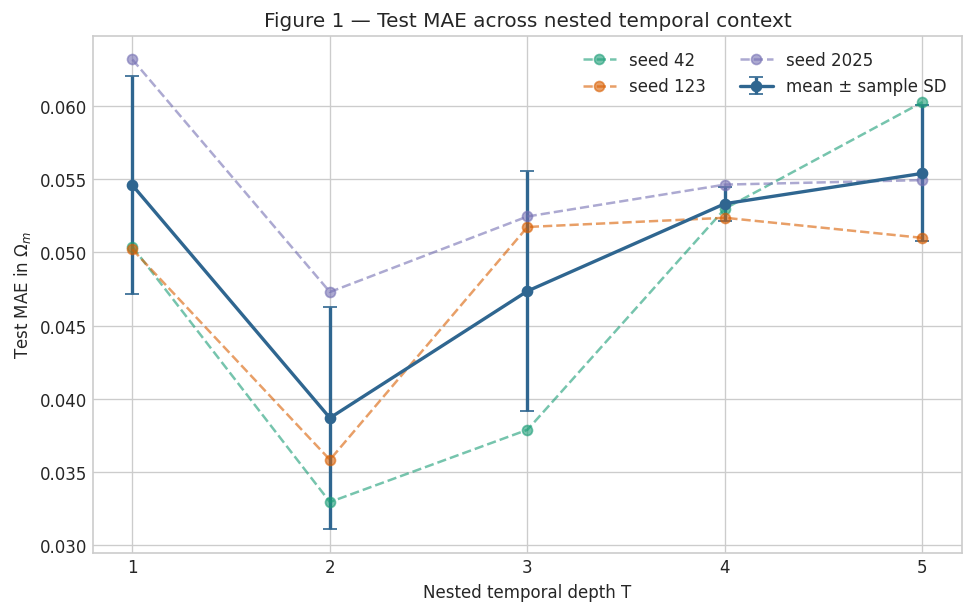

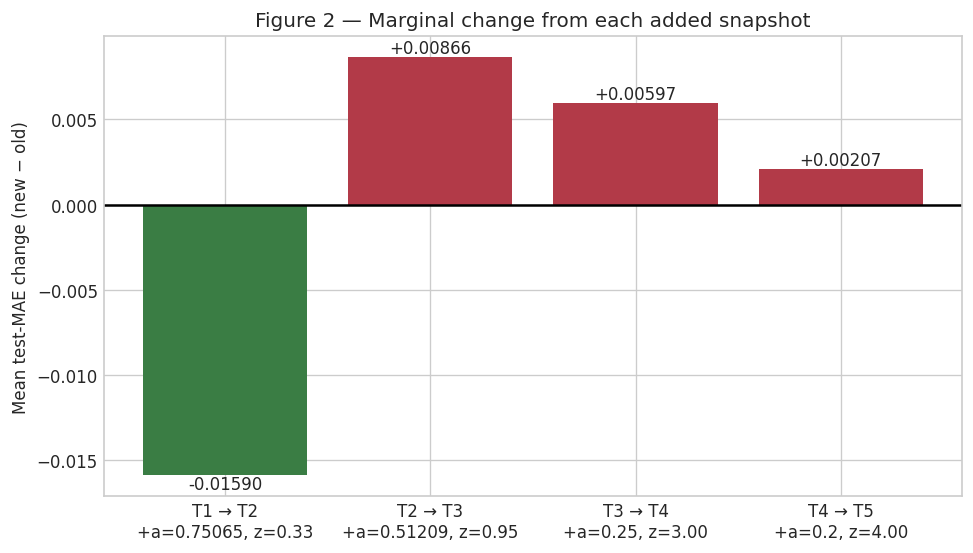

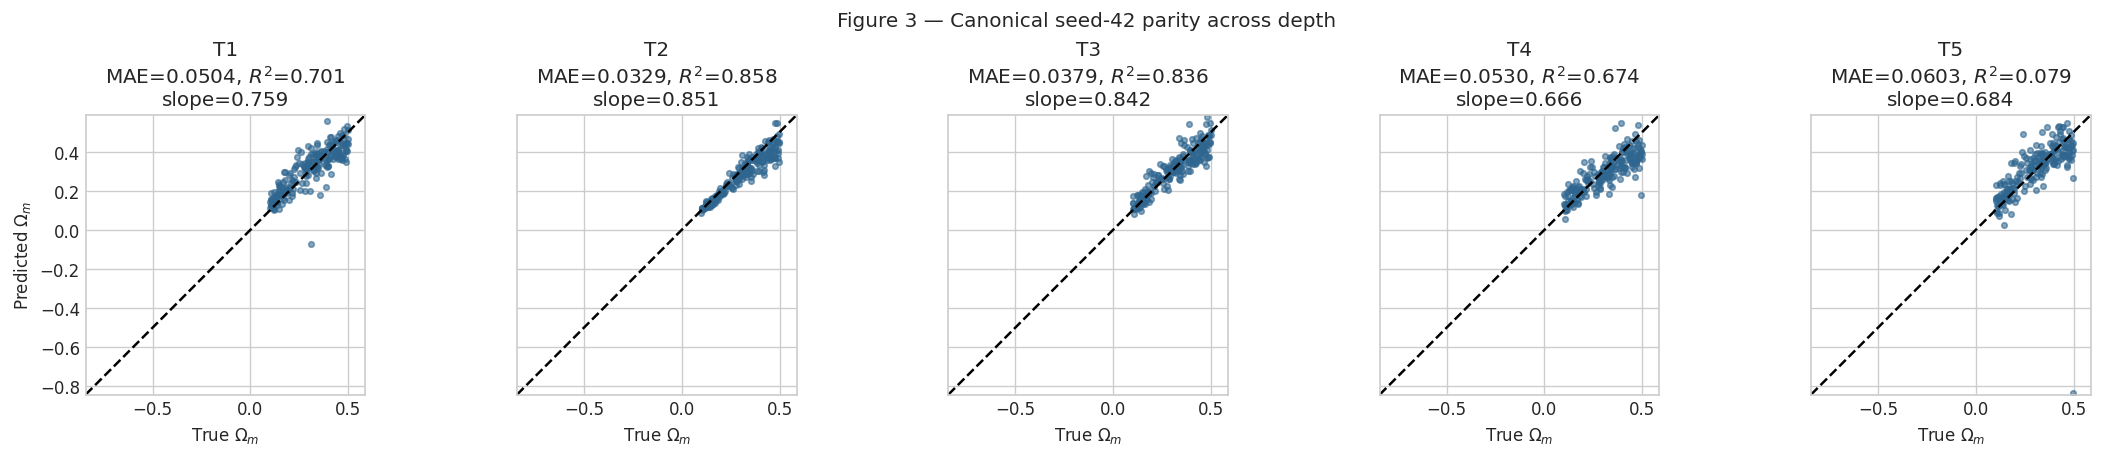

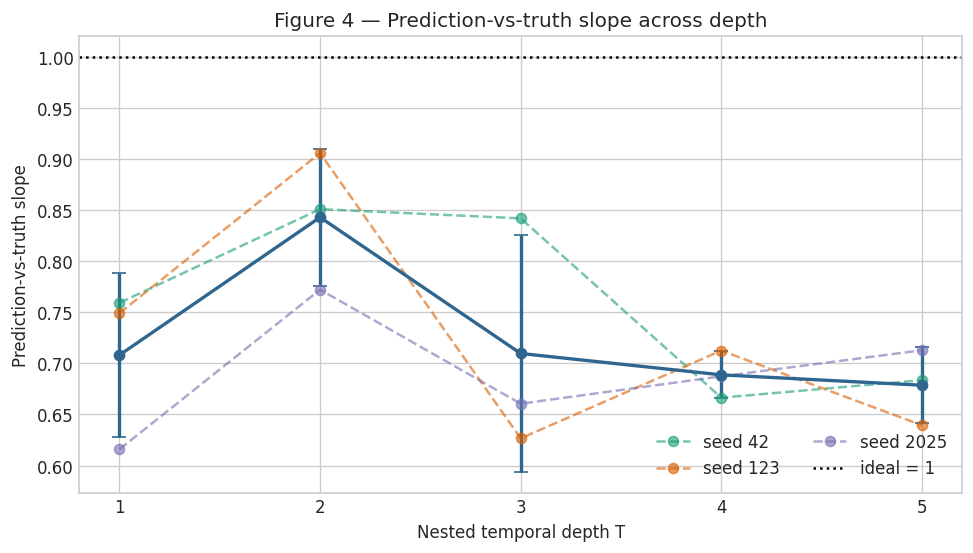

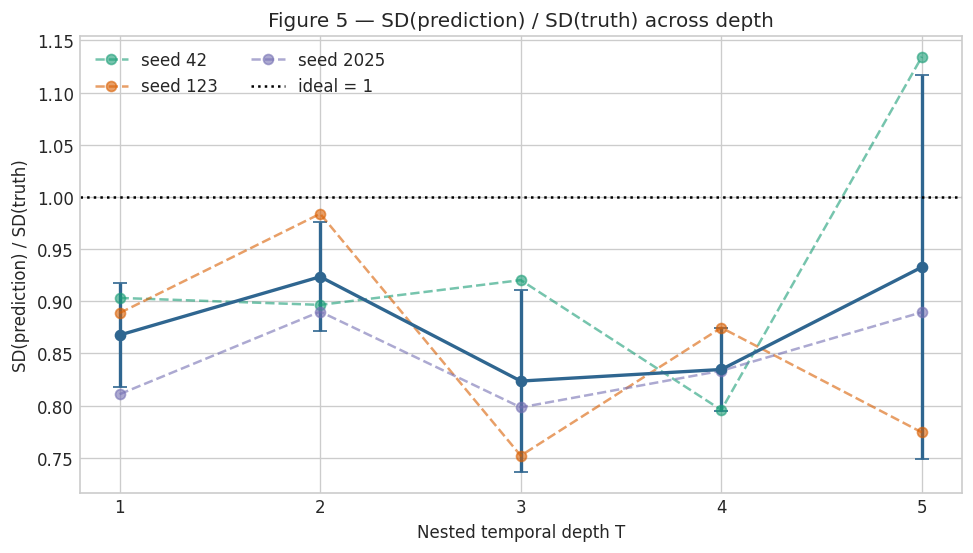

In [2]:
depth=metrics.query("pooling=='mean' and split=='test'").copy()
t1=tab(pd.DataFrame([{"Context":f"T{T}","T":T,"Indices":str(SUB[T]),"Scale factors":str([SNAP[i] for i in SUB[T]]),
 "Redshifts":str([round(1/SNAP[i]-1,5) for i in SUB[T]]),"Readouts":"mean; last diagnostic" if T in (2,5) else "mean"} for T in range(1,6)]),1,"experimental_design")
t2=tab(depth[["T","seed","mae","rmse","r2","best_epoch"]].sort_values(["T","seed"]),2,"depth_per_seed_metrics")
t3=tab(pd.DataFrame([{"T":T,"MAE mean ± SD":ms(depth.query("T==@T").mae),"RMSE mean ± SD":ms(depth.query("T==@T").rmse),
 "R² mean ± SD":ms(depth.query("T==@T").r2),"MAE mean":depth.query("T==@T").mae.mean(),"MAE SD":depth.query("T==@T").mae.std(ddof=1)} for T in range(1,6)]),3,"depth_aggregate_metrics")
adj=[]
for T in range(1,5):
 a=depth.query("T==@T").set_index("seed").mae; b=depth.query("T==@T+1").set_index("seed").mae; sf=SNAP[4-T]
 adj.append({"Transition":f"T{T} → T{T+1}","New scale factor":sf,"New redshift":1/sf-1,"MAE change (new-old)":b.mean()-a.mean(),
  "Percent change":100*(b.mean()-a.mean())/a.mean(),**{f"seed {s} change":b[s]-a[s] for s in SEEDS}})
t4=tab(pd.DataFrame(adj),4,"adjacent_temporal_changes"); base=depth.query("T==1").mae.mean()
t5=tab(pd.DataFrame([{"T":T,"MAE mean":depth.query("T==@T").mae.mean(),"Absolute difference vs T1":depth.query("T==@T").mae.mean()-base,
 "Percent difference vs T1":100*(depth.query("T==@T").mae.mean()-base)/base} for T in range(1,6)]),5,"t1_relative_differences")
for title,x in [("Table 1 — Experimental design",t1),("Table 2 — Per-seed T1–T5 metrics",t2),("Table 3 — T1–T5 mean ± sample SD",t3),
 ("Table 4 — Adjacent changes; negative favors added context",t4),("Table 5 — T1-relative differences",t5)]: display(Markdown("### "+title)); display(x)

# Figures 1–2
fig,ax=plt.subplots(figsize=(8,5)); a=depth.groupby("T").mae.agg(["mean","std"]); ax.errorbar(a.index,a["mean"],yerr=a["std"],fmt="o-",capsize=4,lw=2,color=C["mean"],label="mean ± sample SD")
for s in SEEDS:
 q=depth.query("seed==@s").sort_values("T"); ax.plot(q["T"],q.mae,"o--",alpha=.6,color=SC[s],label=f"seed {s}")
ax.set(xlabel="Nested temporal depth T",ylabel="Test MAE in $\Omega_m$",title="Figure 1 — Test MAE across nested temporal context"); ax.set_xticks(range(1,6)); ax.legend(ncol=2); figsave(fig,1,"temporal_mae_vs_t")
fig,ax=plt.subplots(figsize=(8,4.5)); bars=ax.bar(np.arange(4),t4["MAE change (new-old)"],color=["#3A7D44" if v<0 else "#B23A48" for v in t4["MAE change (new-old)"]]); ax.axhline(0,color="black")
ax.set_xticks(range(4),[f"{r.Transition}\n+a={r['New scale factor']:.5g}, z={r['New redshift']:.2f}" for _,r in t4.iterrows()]); ax.set(ylabel="Mean test-MAE change (new − old)",title="Figure 2 — Marginal change from each added snapshot")
for b,v in zip(bars,t4["MAE change (new-old)"]): ax.text(b.get_x()+b.get_width()/2,v,f"{v:+.5f}",ha="center",va="bottom" if v>=0 else "top")
figsave(fig,2,"marginal_temporal_mae")

# Figure 3
fs=[frames[(T,"mean",42,"test")] for T in range(1,6)]; vals=np.concatenate([f.true_omega_m for f in fs]+[f.pred_omega_m for f in fs]); lo,hi=vals.min()-.01,vals.max()+.01
fig,axs=plt.subplots(1,5,figsize=(18,3.7),sharex=True,sharey=True)
for T,f,ax in zip(range(1,6),fs,axs):
 d=diag.query("T==@T and pooling=='mean' and seed==42").iloc[0]; m=depth.query("T==@T and seed==42").iloc[0]
 ax.scatter(f.true_omega_m,f.pred_omega_m,s=11,alpha=.58,color=C["mean"]); ax.plot([lo,hi],[lo,hi],"k--"); ax.set(title=f"T{T}\nMAE={m.mae:.4f}, $R^2$={m.r2:.3f}\nslope={d.prediction_slope:.3f}",xlim=(lo,hi),ylim=(lo,hi),aspect="equal"); ax.set_xlabel("True $\Omega_m$")
axs[0].set_ylabel("Predicted $\Omega_m$"); fig.suptitle("Figure 3 — Canonical seed-42 parity across depth"); figsave(fig,3,"parity_seed42_t1_t5")
# Figures 4–5
for n,k,label,name in [(4,"prediction_slope","Prediction-vs-truth slope","prediction_slope_vs_t"),(5,"spread_ratio","SD(prediction) / SD(truth)","spread_ratio_vs_t")]:
 fig,ax=plt.subplots(figsize=(8,4.5)); dd=diag.query("pooling=='mean'"); a=dd.groupby("T")[k].agg(["mean","std"]); ax.errorbar(a.index,a["mean"],yerr=a["std"],fmt="o-",capsize=4,lw=2,color=C["mean"])
 for s in SEEDS:
  q=dd.query("seed==@s").sort_values("T"); ax.plot(q["T"],q[k],"o--",alpha=.6,color=SC[s],label=f"seed {s}")
 ax.axhline(1,color="black",ls=":",label="ideal = 1"); ax.set(xlabel="Nested temporal depth T",ylabel=label,title=f"Figure {n} — {label} across depth"); ax.set_xticks(range(1,6)); ax.legend(ncol=2); figsave(fig,n,name)


# Part II — Targeted Temporal Readout Diagnostic

Does replacing equal temporal mean pooling with final-state readout change the strong T2 configuration or rescue the full T5 context? Tables 6–10 and Figures 6–11 report per-seed/aggregate errors, paired deltas, compression, residual structure, generalization, and best epochs.


### Table 6 — T2/T5 mean-versus-last per-seed results

,T,pooling,seed,mae,rmse,r2,best_epoch
11,2,last,42,0.05567995,0.07106763,0.65545559,68
14,2,last,123,0.06082707,0.08361835,0.46306831,34
17,2,last,2025,0.06443160,0.08127203,0.54418249,18
20,2,mean,42,0.03294412,0.04564988,0.85783887,158
23,2,mean,123,0.03583052,0.04520809,0.84305474,163
26,2,mean,2025,0.04728914,0.06008074,0.75089675,78
47,5,last,42,0.04002838,0.05709040,0.77765488,158
50,5,last,123,0.06001575,0.07544994,0.56284675,95
53,5,last,2025,0.06058779,0.07596765,0.60174050,47
56,5,mean,42,0.06025856,0.11618994,0.07904476,107


### Table 7 — Pooling mean ± sample SD

,T,Pooling,MAE mean ± SD,RMSE mean ± SD,R² mean ± SD
0,2,mean,0.038687925 ± 0.007587392,0.050312907 ± 0.008462080,0.817263455 ± 0.057948657
1,2,last,0.060312872 ± 0.004398425,0.078652671 ± 0.006672772,0.554235463 ± 0.096586817
2,5,mean,0.055392261 ± 0.004653484,0.084740757 ± 0.027509475,0.462177425 ± 0.332426521
3,5,last,0.053543974 ± 0.011708339,0.069502663 ± 0.010752454,0.647414044 ± 0.114456050


### Table 8 — Pooling delta; negative favors last

...

,T,Pooling,Bias mean ± SD,Spread ratio mean ± SD,Prediction slope mean ± SD,Residual slope mean ± SD
0,2,mean,-0.005788258 ± 0.016047288,0.923434673 ± 0.052386400,0.842923378 ± 0.067157319,-0.157076622 ± 0.067157319
1,2,last,-0.001869711 ± 0.013125596,0.862542569 ± 0.068337987,0.654823016 ± 0.095546130,-0.345176984 ± 0.095546130
2,5,mean,0.000156604 ± 0.007399630,0.932659759 ± 0.183852730,0.678631744 ± 0.036923480,-0.321368256 ± 0.036923480
3,5,last,0.007497454 ± 0.011623190,0.853553032 ± 0.098304503,0.696771079 ± 0.137619039,-0.303228921 ± 0.137619039


### Table 10 — Generalization diagnostics

split,T,pooling,Test MAE,Train MAE,Validation MAE,test - train,validation - train,test - validation
0,1,mean,0.05458452,0.03967350,0.05422395,0.01491102,0.01455045,0.00036057
1,2,last,0.06031287,0.04903731,0.05929010,0.01127556,0.01025279,0.00102278
2,2,mean,0.03868793,0.02152830,0.04067020,0.01715962,0.01914190,-0.00198227
3,3,mean,0.04735258,0.03020298,0.05180451,0.01714960,0.02160154,-0.00445194
4,4,mean,0.05332199,0.03998590,0.05232412,0.01333609,0.01233822,0.00099787
5,5,last,0.05354397,0.03635647,0.04986920,0.01718750,0.01351273,0.00367477
6,5,mean,0.05539226,0.03235929,0.05251554,0.02303297,0.02015625,0.00287672


Low/high residual tendencies use the lowest/highest truth quartiles.

,T,pooling,seed,bias,true_sd,pred_sd,spread_ratio,prediction_slope,residual_slope,low_quartile_residual,high_quartile_residual
3,2,last,42,0.00353248,0.12137585,0.11346977,0.93486282,0.76513767,-0.23486233,0.03411982,-0.04730208
4,2,last,123,0.00769270,0.11439975,0.09766551,0.85372137,0.59822643,-0.40177357,0.05950409,-0.06542008
5,2,last,2025,-0.01683431,0.12067815,0.09642709,0.79904352,0.60110496,-0.39889504,0.03559639,-0.08303570
6,2,mean,42,-0.02429478,0.12137585,0.10881149,0.89648383,0.85089355,-0.14910645,-0.00668188,-0.05568526
7,2,mean,123,0.00266069,0.11439975,0.11254759,0.98380971,0.90573996,-0.09426004,0.00454442,-0.02503394
8,2,mean,2025,0.00426931,0.12067815,0.10740482,0.89001048,0.77213662,-0.22786338,0.02843640,-0.04568132
15,5,last,42,0.00526162,0.12137585,0.11704547,0.96432253,0.85473071,-0.14526929,0.02141700,-0.01973779
16,5,last,123,0.02007614,0.11439975,0.09376749,0.81964767,0.63281009,-0.36718991,0.05771466,-0.04360347
17,5,last,2025,-0.00284540,0.12067815,0.09372938,0.77668890,0.60277243,-0.39722757,0.04570304,-0.07520891
18,5,mean,42,0.00467467,0.12137585,0.13767325,1.13427221,0.68355448,-0.31644552,0.03230122,-0.06271778


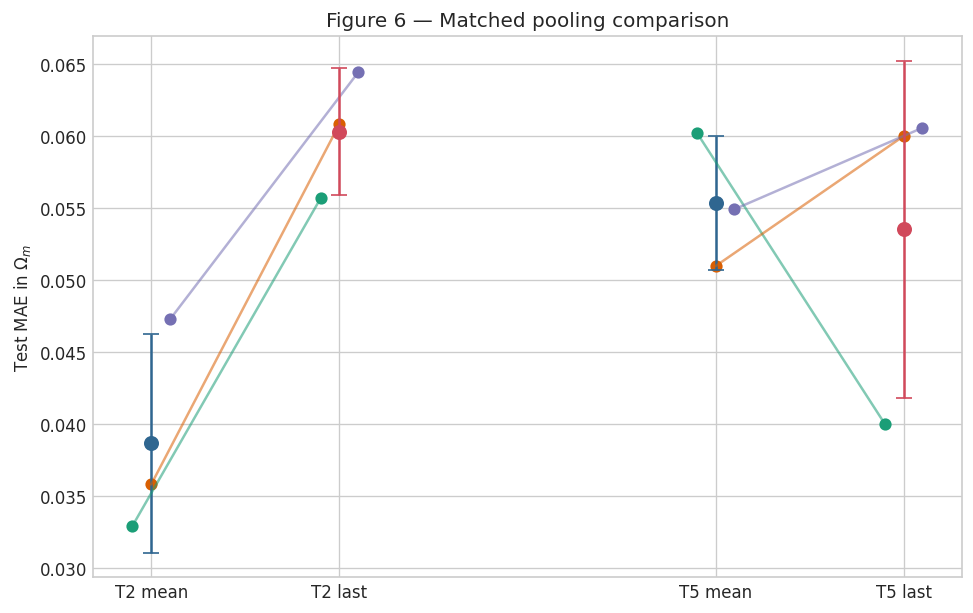

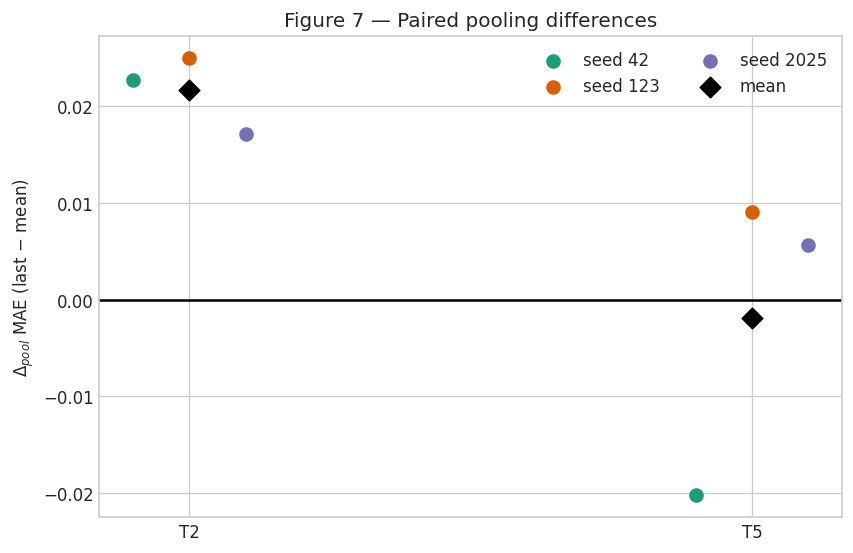

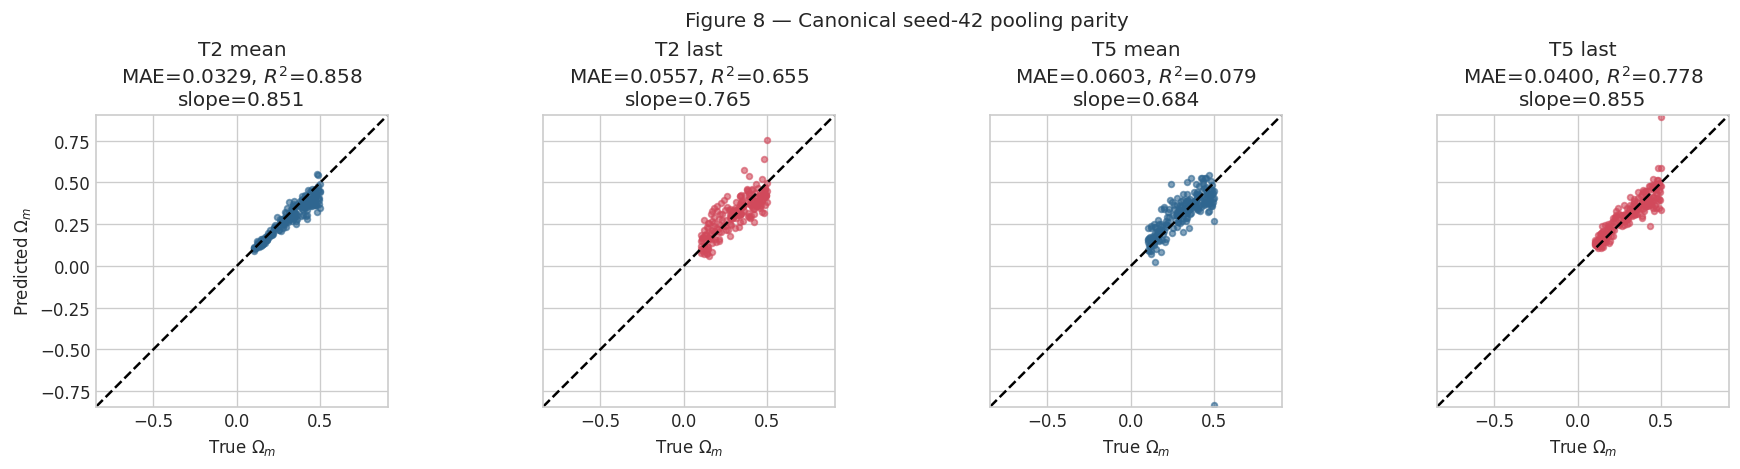

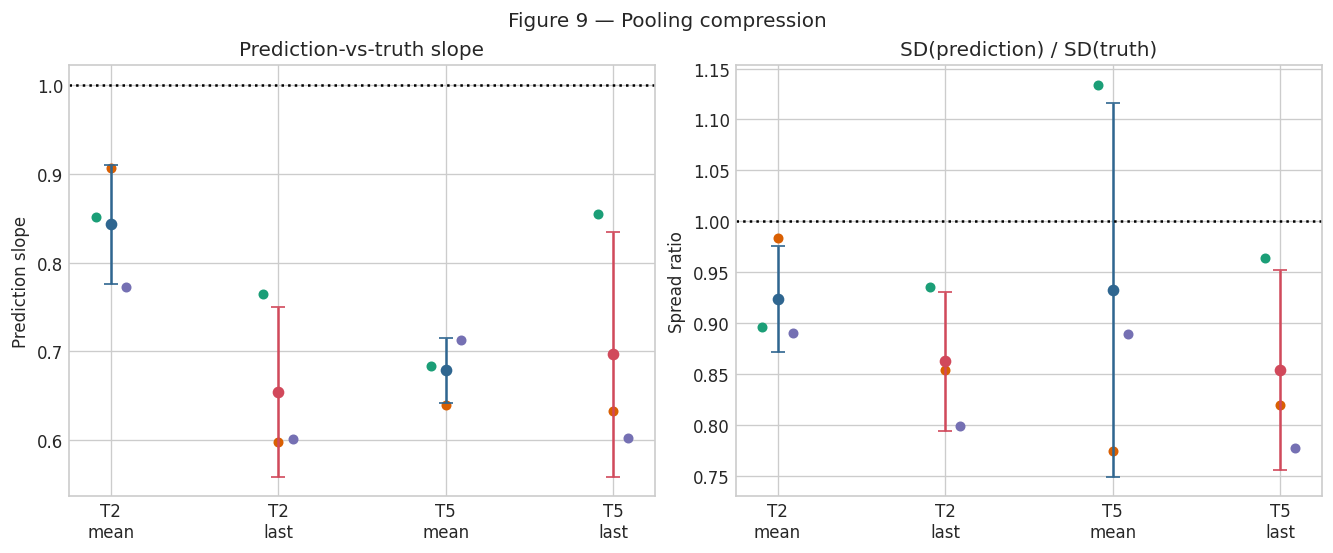

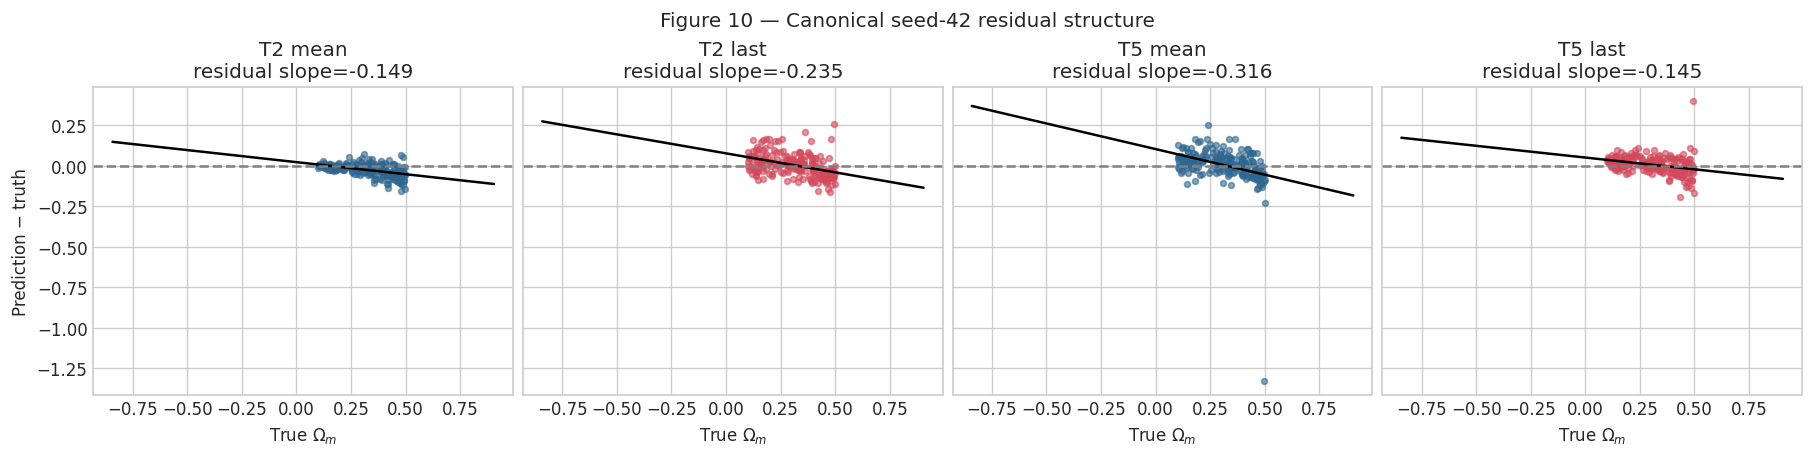

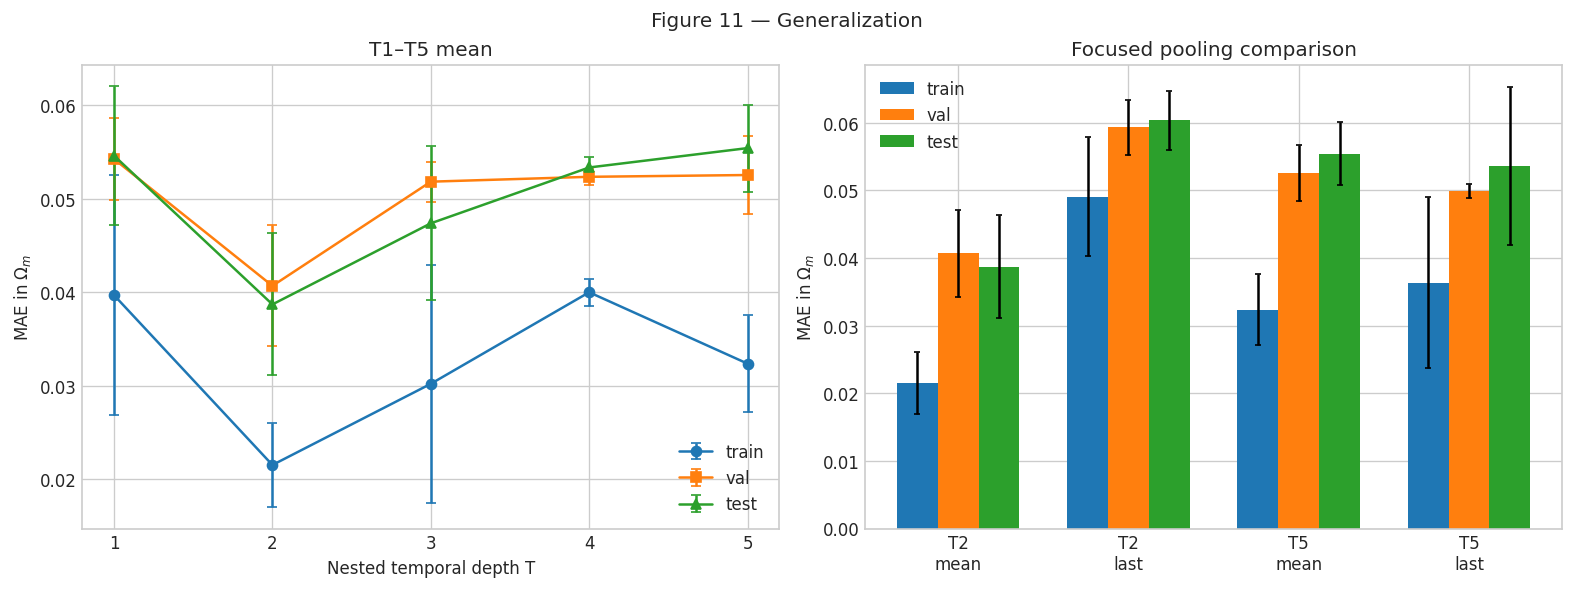

In [3]:
pool=metrics.query("T in [2,5] and split=='test'").copy(); keys=[(2,"mean"),(2,"last"),(5,"mean"),(5,"last")]
t6=tab(pool[["T","pooling","seed","mae","rmse","r2","best_epoch"]].sort_values(["T","pooling","seed"]),6,"pooling_per_seed_metrics")
t7=tab(pd.DataFrame([{"T":T,"Pooling":p,"MAE mean ± SD":ms(pool.query("T==@T and pooling==@p").mae),"RMSE mean ± SD":ms(pool.query("T==@T and pooling==@p").rmse),"R² mean ± SD":ms(pool.query("T==@T and pooling==@p").r2)} for T,p in keys]),7,"pooling_aggregate_metrics")
drows=[]
for T in (2,5):
 for s in SEEDS:
  a=pool.query("T==@T and pooling=='mean' and seed==@s").mae.iloc[0]; b=pool.query("T==@T and pooling=='last' and seed==@s").mae.iloc[0]
  drows.append({"T":T,"seed":s,"MAE mean":a,"MAE last":b,"Delta_pool (last-mean)":b-a,"Percent vs mean":100*(b-a)/a})
for T in (2,5):
 q=pd.DataFrame(drows).query("T==@T"); drows.append({"T":T,"seed":"mean","MAE mean":q["MAE mean"].mean(),"MAE last":q["MAE last"].mean(),"Delta_pool (last-mean)":q["Delta_pool (last-mean)"].mean(),"Percent vs mean":100*q["Delta_pool (last-mean)"].mean()/q["MAE mean"].mean()})
t8=tab(pd.DataFrame(drows),8,"pooling_deltas"); pdg=diag.query("T in [2,5]")
t9=tab(pd.DataFrame([{"T":T,"Pooling":p,"Bias mean ± SD":ms(pdg.query("T==@T and pooling==@p").bias),"Spread ratio mean ± SD":ms(pdg.query("T==@T and pooling==@p").spread_ratio),"Prediction slope mean ± SD":ms(pdg.query("T==@T and pooling==@p").prediction_slope),"Residual slope mean ± SD":ms(pdg.query("T==@T and pooling==@p").residual_slope)} for T,p in keys]),9,"compression_diagnostics")
ga=metrics.query("pooling=='mean' or T in [2,5]").groupby(["T","pooling","split"]).mae.agg(["mean","std"]).reset_index(); gp=ga.pivot(index=["T","pooling"],columns="split",values="mean").reset_index()
gp["test - train"]=gp.test-gp.train; gp["validation - train"]=gp.val-gp.train; gp["test - validation"]=gp.test-gp.val
t10=tab(gp.rename(columns={"train":"Train MAE","val":"Validation MAE","test":"Test MAE"}),10,"generalization_diagnostics")
for title,x in [("Table 6 — T2/T5 mean-versus-last per-seed results",t6),("Table 7 — Pooling mean ± sample SD",t7),("Table 8 — Pooling delta; negative favors last",t8),("Table 9 — Compression diagnostics",t9),("Table 10 — Generalization diagnostics",t10)]: display(Markdown("### "+title)); display(x)
display(Markdown("Low/high residual tendencies use the lowest/highest truth quartiles.")); display(pdg[["T","pooling","seed","bias","true_sd","pred_sd","spread_ratio","prediction_slope","residual_slope","low_quartile_residual","high_quartile_residual"]])

# Figures 6–7
pos={(2,"mean"):0,(2,"last"):1,(5,"mean"):3,(5,"last"):4}; fig,ax=plt.subplots(figsize=(8,5))
for (T,p),x in pos.items():
 q=pool.query("T==@T and pooling==@p"); ax.errorbar(x,q.mae.mean(),yerr=q.mae.std(ddof=1),fmt="o",ms=8,capsize=5,color=C[p])
 for s,j in zip(SEEDS,[-.1,0,.1]): ax.scatter(x+j,q.query("seed==@s").mae,s=40,color=SC[s])
 if p=="mean":
  aa=q.set_index("seed"); bb=pool.query("T==@T and pooling=='last'").set_index("seed")
  for s,j in zip(SEEDS,[-.1,0,.1]): ax.plot([x+j,x+1+j],[aa.loc[s,"mae"],bb.loc[s,"mae"]],color=SC[s],alpha=.55)
ax.set_xticks(list(pos.values()),[f"T{T} {p}" for T,p in pos]); ax.set(ylabel="Test MAE in $\Omega_m$",title="Figure 6 — Matched pooling comparison"); figsave(fig,6,"pooling_mae_comparison")
fig,ax=plt.subplots(figsize=(7,4.5)); sd=t8.query("seed!='mean'")
for T,x in [(2,0),(5,1)]:
 q=sd.query("T==@T")
 for s,j in zip(SEEDS,[-.1,0,.1]): ax.scatter(x+j,q.query("seed==@s")["Delta_pool (last-mean)"],s=60,color=SC[s],label=f"seed {s}" if T==2 else None)
 ax.scatter(x,q["Delta_pool (last-mean)"].mean(),marker="D",s=75,color="black",label="mean" if T==2 else None)
ax.axhline(0,color="black"); ax.set_xticks([0,1],["T2","T5"]); ax.set(ylabel="$\Delta_{pool}$ MAE (last − mean)",title="Figure 7 — Paired pooling differences"); ax.legend(ncol=2); figsave(fig,7,"pooling_paired_deltas")
# Figure 8
ks=keys; fs=[frames[(T,p,42,"test")] for T,p in ks]; vals=np.concatenate([f.true_omega_m for f in fs]+[f.pred_omega_m for f in fs]); lo2,hi2=vals.min()-.01,vals.max()+.01
fig,axs=plt.subplots(1,4,figsize=(15,3.8),sharex=True,sharey=True)
for (T,p),f,ax in zip(ks,fs,axs):
 d=pdg.query("T==@T and pooling==@p and seed==42").iloc[0]; m=pool.query("T==@T and pooling==@p and seed==42").iloc[0]
 ax.scatter(f.true_omega_m,f.pred_omega_m,s=12,alpha=.6,color=C[p]); ax.plot([lo2,hi2],[lo2,hi2],"k--"); ax.set(title=f"T{T} {p}\nMAE={m.mae:.4f}, $R^2$={m.r2:.3f}\nslope={d.prediction_slope:.3f}",xlim=(lo2,hi2),ylim=(lo2,hi2),aspect="equal"); ax.set_xlabel("True $\Omega_m$")
axs[0].set_ylabel("Predicted $\Omega_m$"); fig.suptitle("Figure 8 — Canonical seed-42 pooling parity"); figsave(fig,8,"pooling_parity_seed42")
# Figure 9
fig,axs=plt.subplots(1,2,figsize=(11,4.5))
for ax,k,label in zip(axs,["prediction_slope","spread_ratio"],["Prediction slope","Spread ratio"]):
 for i,(T,p) in enumerate(ks):
  q=pdg.query("T==@T and pooling==@p"); ax.errorbar(i,q[k].mean(),yerr=q[k].std(ddof=1),fmt="o",capsize=4,color=C[p])
  for s,j in zip(SEEDS,[-.09,0,.09]): ax.scatter(i+j,q.query("seed==@s")[k],s=25,color=SC[s])
 ax.axhline(1,color="black",ls=":"); ax.set_xticks(range(4),[f"T{T}\n{p}" for T,p in ks]); ax.set_ylabel(label)
axs[0].set_title("Prediction-vs-truth slope"); axs[1].set_title("SD(prediction) / SD(truth)"); fig.suptitle("Figure 9 — Pooling compression"); figsave(fig,9,"pooling_compression")
# Figure 10
fig,axs=plt.subplots(1,4,figsize=(15,3.7),sharex=True,sharey=True)
for (T,p),f,ax in zip(ks,fs,axs):
 d=pdg.query("T==@T and pooling==@p and seed==42").iloc[0]; res=f.pred_omega_m-f.true_omega_m; xx=np.array([lo2,hi2])
 ax.scatter(f.true_omega_m,res,s=12,alpha=.58,color=C[p]); ax.plot(xx,d.residual_intercept+d.residual_slope*xx,color="black"); ax.axhline(0,color="gray",ls="--"); ax.set(title=f"T{T} {p}\nresidual slope={d.residual_slope:.3f}"); ax.set_xlabel("True $\Omega_m$")
axs[0].set_ylabel("Prediction − truth"); fig.suptitle("Figure 10 — Canonical seed-42 residual structure"); figsave(fig,10,"pooling_residuals")
# Figure 11
fig,axs=plt.subplots(1,2,figsize=(13,4.8))
for split,mk in [("train","o"),("val","s"),("test","^")]:
 q=ga.query("pooling=='mean' and split==@split"); axs[0].errorbar(q["T"],q["mean"],yerr=q["std"],marker=mk,capsize=3,label=split)
axs[0].set(xlabel="Nested temporal depth T",ylabel="MAE in $\Omega_m$",title="T1–T5 mean"); axs[0].set_xticks(range(1,6)); axs[0].legend()
x=np.arange(4); w=.24
for j,split in enumerate(["train","val","test"]):
 vals=[]; errs=[]
 for T,p in ks:
  q=ga.query("T==@T and pooling==@p and split==@split").iloc[0]; vals.append(q["mean"]); errs.append(q["std"])
 axs[1].bar(x+(j-1)*w,vals,w,yerr=errs,capsize=2,label=split)
axs[1].set_xticks(x,[f"T{T}\n{p}" for T,p in ks]); axs[1].set(ylabel="MAE in $\Omega_m$",title="Focused pooling comparison"); axs[1].legend(); fig.suptitle("Figure 11 — Generalization"); figsave(fig,11,"generalization")


# 3 — Static context, provenance, and integrated interpretation

Static Top1500 is independently reproduced from saved predictions and shown separately from the temporal-depth curve. Table 11 provides context; Table 12 is the complete 12-cell pooling inventory with experiment paths, subsets, SHA identities, commits, checkpoints, and epochs.


### Table 11 — Static contextual comparison

,Configuration,MAE mean,MAE SD
0,Static GCN,0.03788662,0.00094155
1,T1 mean,0.05458452,0.00743642
2,T2 mean,0.03868793,0.00758739
3,T3 mean,0.04735258,0.00821261
4,T4 mean,0.05332199,0.00117041
5,T5 mean,0.05539226,0.00465348
6,T2 last,0.06031287,0.00439842
7,T5 last,0.05354397,0.01170834


### Table 12 — Complete pooling provenance/control inventory

,T,pooling,seed,origin,experiment_path,snapshot_indices,snapshot_values,dataset_path,dataset_sha256,split_manifest_path,split_manifest_sha256,source_commit,checkpoint_sha256,best_epoch,trainable_parameters,branch_at_analysis,HEAD_at_analysis,temporal_protocol,k,box_size
3,2,last,42,new,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,f5556ec5c193e7cb80f2231705edbdae32d4de206889de...,617e6af48b5c9c310d06d61b499955d3417fcbab,75fcca8fe27e8b8ef35ec5e5851fe2ee262033b0692384...,68,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
4,2,last,123,new,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,18a295106ec844848053f3040d2be3cdf73a443010be31...,617e6af48b5c9c310d06d61b499955d3417fcbab,24096a0ca6b0ae1c56d7b49484eb52554de18a5a0d7787...,34,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
5,2,last,2025,new,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,c233c0631b1a24d963ffccc7c6389054fddf135a7aabc4...,617e6af48b5c9c310d06d61b499955d3417fcbab,14bc1ba66d94158a08586ebd393b04177e955e09c85bc4...,18,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
6,2,mean,42,reused,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,f5556ec5c193e7cb80f2231705edbdae32d4de206889de...,2989938c736ed83358944352d8b9f78907df1bf8,a3f6ceaf0589e635e95348ba97a7c8247db5844bf6308c...,158,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
7,2,mean,123,reused,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,18a295106ec844848053f3040d2be3cdf73a443010be31...,2989938c736ed83358944352d8b9f78907df1bf8,9ad5ba511e78910c7d6dc8b0db8ddf3a18220cb2ad86e1...,163,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
8,2,mean,2025,reused,experiments/evolvegcn_h_u1000_top1500_t2_ctxsu...,"[3, 4]","[0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,c233c0631b1a24d963ffccc7c6389054fddf135a7aabc4...,2989938c736ed83358944352d8b9f78907df1bf8,9875c799e7b8653e144026598548da9827bddd74a12fff...,78,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
15,5,last,42,new,experiments/evolvegcn_h_u1000_top1500_t5_ctxsu...,"[0, 1, 2, 3, 4]","[0.2, 0.25, 0.51209, 0.75065, 1.0]",data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...,configs/splits/u1000_top1500_none_k8_sparse/se...,f5556ec5c193e7cb80f2231705edbdae32d4de206889de...,617e6af48b5c9c310d06d61b499955d3417fcbab,d56c529a8ee8822593c551673d293409a65cc5995da6ec...,158,3408097,thesis-sparse-integrity-hardening,617e6af48b5c9c310d06d61b499955d3417fcbab,nested_suffix_context_v1,8,25.00000000
16,5,last,123,new,experiments/evolvegcn_h_u1000_top1500_t5_ctxsu...,"[0, 1, 2, 3, 4]","[0.2, 0.25, 0.51209, 0.75065, 1.0]",da

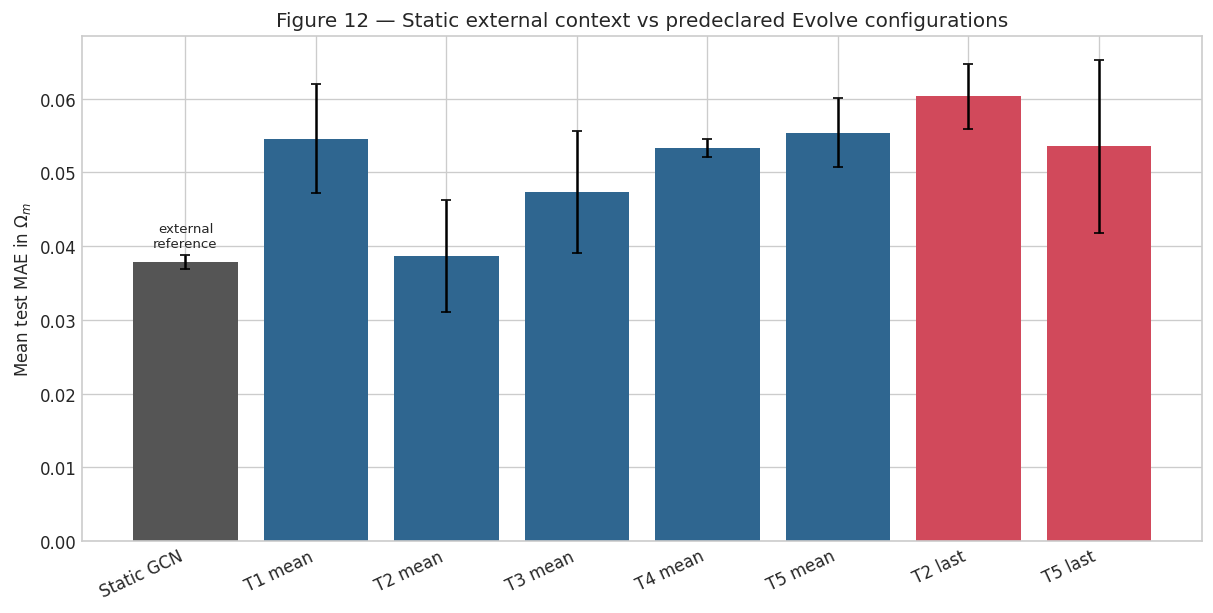

### Paired wins (tie tolerance 1e-12), descriptive interaction, and epochs

,T,LAST wins,MEAN wins,ties
0,2,0,3,0
1,5,1,2,0


,seed,I
0,42,-0.04296601
1,123,-0.01596652
2,2025,-0.01148717


Aggregate descriptive I = -0.023473234108925656


,T,pooling,mean,min,max
0,2,last,40.00000000,18,68
1,2,mean,133.00000000,78,163
2,5,last,100.00000000,47,158
3,5,mean,80.33333333,64,107


### Required effect sizes

,Comparison,Absolute MAE difference,Percent difference
0,T2 mean vs T1 mean,-0.01589659,-29.12289818
1,T5 mean vs T2 mean,0.01670434,43.17712988
2,T2 last vs T2 mean,0.02162495,55.89585711
3,T5 last vs T5 mean,-0.00184829,-3.33672381
4,T5 last vs T2 mean,0.01485605,38.39970450
5,best observed Evolve vs Static,0.00080131,2.11500961
6,T5 last vs Static,0.01565735,41.32687155


In [4]:
sr=[]
for ref in dp["static_external_references"]:
 s=ref["seed"]; exp=ROOT/ref["experiment_path"]; c=js(exp/"config.json"); saved=js(exp/"metrics.json"); assert c["dataset_identity"]==DSHA and c["split_manifest_sha256"]==pr[(2,"mean",s)]["split_manifest_sha256"]
 for split,n in COUNTS.items():
  f=pd.read_csv(exp/f"predictions/{split}_predictions.csv"); assert len(f)==n and f.universe_id.tolist()==mans[s][f"{split}_ids"]; mm=met(f)
  for k in ("mse","rmse","mae","r2"): assert math.isclose(mm[k],saved[split][k],abs_tol=TOL,rel_tol=0)
  if split=="test": sr.append(dict(Configuration="Static GCN",seed=s,**mm,experiment_path=ref["experiment_path"],source_commit=c.get("training_git_commit"),checkpoint_sha256=sha(exp/"checkpoints/best_model.pt")))
static=pd.DataFrame(sr); cr=[{"Configuration":"Static GCN","MAE mean":static.mae.mean(),"MAE SD":static.mae.std(ddof=1)}]
for T in range(1,6):
 q=depth.query("T==@T"); cr.append({"Configuration":f"T{T} mean","MAE mean":q.mae.mean(),"MAE SD":q.mae.std(ddof=1)})
for T in (2,5):
 q=pool.query("T==@T and pooling=='last'"); cr.append({"Configuration":f"T{T} last","MAE mean":q.mae.mean(),"MAE SD":q.mae.std(ddof=1)})
t11=tab(pd.DataFrame(cr),11,"static_context")
t12=inventory[["T","pooling","seed","origin","experiment_path","snapshot_indices","snapshot_values","dataset_path","dataset_sha256","split_manifest_path","split_manifest_sha256","source_commit","checkpoint_sha256","best_epoch","trainable_parameters"]].copy()
t12["branch_at_analysis"]=branch; t12["HEAD_at_analysis"]=head; t12["temporal_protocol"]="nested_suffix_context_v1"; t12["k"]=meta["k"]; t12["box_size"]=meta["box_size"]; t12=tab(t12,12,"provenance_control_inventory")
display(Markdown("### Table 11 — Static contextual comparison")); display(t11); display(Markdown("### Table 12 — Complete pooling provenance/control inventory")); display(t12)
fig,ax=plt.subplots(figsize=(10,5)); ax.bar(range(len(t11)),t11["MAE mean"],yerr=t11["MAE SD"],capsize=3,color=["#555"]+[C["mean"]]*5+[C["last"]]*2); ax.set_xticks(range(len(t11)),t11.Configuration,rotation=25,ha="right"); ax.set(ylabel="Mean test MAE in $\Omega_m$",title="Figure 12 — Static external context vs predeclared Evolve configurations"); ax.text(0,t11.iloc[0]["MAE mean"]+.002,"external\nreference",ha="center",fontsize=8); figsave(fig,12,"static_context")

WIN_TOL=1e-12; wins={}
for T in (2,5):
 d=t8.query("T==@T and seed!='mean'")["Delta_pool (last-mean)"].astype(float); wins[T]={"LAST wins":int((d<-WIN_TOL).sum()),"MEAN wins":int((d>WIN_TOL).sum()),"ties":int((abs(d)<=WIN_TOL).sum())}
inter=pd.DataFrame([{"seed":s,"I":t8.query("T==5 and seed==@s")["Delta_pool (last-mean)"].iloc[0]-t8.query("T==2 and seed==@s")["Delta_pool (last-mean)"].iloc[0]} for s in SEEDS]); I=inter.I.mean()
epochs=pool.groupby(["T","pooling"]).best_epoch.agg(["mean","min","max"]).reset_index()
display(Markdown("### Paired wins (tie tolerance 1e-12), descriptive interaction, and epochs")); display(pd.DataFrame([{"T":T,**wins[T]} for T in (2,5)])); display(inter); print("Aggregate descriptive I =",I); display(epochs)
best=t11.query("Configuration!='Static GCN'").sort_values("MAE mean").iloc[0]; best_config,best_mae=best.Configuration,best["MAE mean"]
cand=metrics.query("split=='test' and (pooling=='mean' or T in [2,5])"); seed_best=[]
for s in SEEDS:
 r=cand.query("seed==@s").sort_values("mae").iloc[0]; seed_best.append((s,f"T{int(r['T'])} {r.pooling}",r.mae))
def am(T,p): return metrics.query("T==@T and pooling==@p and split=='test'").mae.mean()
effects=[]
pairs=[((2,"mean"),(1,"mean"),"T2 mean vs T1 mean"),((5,"mean"),(2,"mean"),"T5 mean vs T2 mean"),((2,"last"),(2,"mean"),"T2 last vs T2 mean"),((5,"last"),(5,"mean"),"T5 last vs T5 mean"),((5,"last"),(2,"mean"),"T5 last vs T2 mean")]
for a,b,n in pairs:
 av,bv=am(*a),am(*b); effects.append({"Comparison":n,"Absolute MAE difference":av-bv,"Percent difference":100*(av-bv)/bv})
sm=static.mae.mean(); effects += [{"Comparison":"best observed Evolve vs Static","Absolute MAE difference":best_mae-sm,"Percent difference":100*(best_mae-sm)/sm},{"Comparison":"T5 last vs Static","Absolute MAE difference":am(5,"last")-sm,"Percent difference":100*(am(5,"last")-sm)/sm}]
display(Markdown("### Required effect sizes")); display(pd.DataFrame(effects))
d2=t8.query("T==2 and seed=='mean'").iloc[0]; d5=t8.query("T==5 and seed=='mean'").iloc[0]
if d5["Delta_pool (last-mean)"]<0 and wins[5]["LAST wins"]==3: verdict="STRONG SUPPORT" if abs(d5["Percent vs mean"])>=20 else ("MODERATE SUPPORT" if abs(d5["Percent vs mean"])>=10 else "WEAK/INCONSISTENT SUPPORT")
elif d5["Delta_pool (last-mean)"]<0: verdict="WEAK/INCONSISTENT SUPPORT"
elif abs(d5["Percent vs mean"])<5: verdict="NO SUPPORT"
else: verdict="EVIDENCE AGAINST"
out=[]
if d5["Delta_pool (last-mean)"]<0 and abs(d5["Percent vs mean"])>=10: out.append("A")
if abs(d5["Percent vs mean"])<5: out.append("B")
if d5["Delta_pool (last-mean)"]>0: out.append("C")
if d2["Delta_pool (last-mean)"]<0 and abs(d2["Percent vs mean"])>=10: out.append("D")
if d2["Delta_pool (last-mean)"]>0 and d5["Delta_pool (last-mean)"]<0: out.append("E")
if any(0<wins[T]["LAST wins"]<3 for T in (2,5)): out.append("F")


In [5]:
def av(T,p,k): return pdg.query("T==@T and pooling==@p")[k].mean()
def close(T,k,ideal):
 a=pdg.query("T==@T and pooling=='mean'").set_index("seed")[k]; b=pdg.query("T==@T and pooling=='last'").set_index("seed")[k]
 return int((abs(b-ideal)<abs(a-ideal)).sum()),abs(b.mean()-ideal)-abs(a.mean()-ideal)
r2m=t10.query("T==2 and pooling=='mean'").iloc[0]; r2l=t10.query("T==2 and pooling=='last'").iloc[0]; r5m=t10.query("T==5 and pooling=='mean'").iloc[0]; r5l=t10.query("T==5 and pooling=='last'").iloc[0]
t2word="improves" if d2["Delta_pool (last-mean)"]<0 else "degrades"
rob=lambda T:"ROBUST ACROSS ALL 3" if max(wins[T]["LAST wins"],wins[T]["MEAN wins"])==3 else ("MAJORITY 2/3" if max(wins[T]["LAST wins"],wins[T]["MEAN wins"])==2 else "CONTRADICTORY")
bestT=int(depth.groupby("T").mae.mean().idxmin()); t1s=depth.query("T==1").set_index("seed").mae; t2s=depth.query("T==2").set_index("seed").mae
display(Markdown(f"""# 4 — Integrated findings and explicit answers

### T5 rescue verdict — **{verdict}**

T5 last changes mean test MAE by **{d5['Delta_pool (last-mean)']:+.9f}** (**{d5['Percent vs mean']:+.2f}%**) with {wins[5]} ({rob(5)}). RMSE changes by {metrics.query("T==5 and pooling=='last' and split=='test'").rmse.mean()-metrics.query("T==5 and pooling=='mean' and split=='test'").rmse.mean():+.9f}; \(R^2\) changes by {metrics.query("T==5 and pooling=='last' and split=='test'").r2.mean()-metrics.query("T==5 and pooling=='mean' and split=='test'").r2.mean():+.9f}. Prediction slope moves {av(5,'mean','prediction_slope'):.4f}→{av(5,'last','prediction_slope'):.4f}; spread ratio {av(5,'mean','spread_ratio'):.4f}→{av(5,'last','spread_ratio'):.4f}. Train/validation/test changes are {r5l['Train MAE']-r5m['Train MAE']:+.6f}, {r5l['Validation MAE']-r5m['Validation MAE']:+.6f}, {r5l['Test MAE']-r5m['Test MAE']:+.6f}; the test–train gap changes by {r5l['test - train']-r5m['test - train']:+.6f}.

The verdict uses observed magnitude (10% moderate; 20% strong) and three-seed consistency, cross-checked against RMSE, \(R^2\), compression, and generalization. It is descriptive, not a significance claim. At most it supports pooling as a contributor, never as the sole cause.

### T2 readout verdict

Last **{t2word}** T2 by {d2['Delta_pool (last-mean)']:+.9f} ({d2['Percent vs mean']:+.2f}%), with {wins[2]} ({rob(2)}). Train/validation/test changes are {r2l['Train MAE']-r2m['Train MAE']:+.6f}, {r2l['Validation MAE']-r2m['Validation MAE']:+.6f}, {r2l['Test MAE']-r2m['Test MAE']:+.6f}. Thus readout is not assumed to have a depth-independent effect.

### Compression and residual structure

At T2, last moves prediction slope, spread ratio, and residual slope closer to their ideals for {close(2,'prediction_slope',1)[0]}/3, {close(2,'spread_ratio',1)[0]}/3, and {close(2,'residual_slope',0)[0]}/3 seeds. At T5 the counts are {close(5,'prediction_slope',1)[0]}/3, {close(5,'spread_ratio',1)[0]}/3, and {close(5,'residual_slope',0)[0]}/3. Low/high-quartile tendencies in Table 9's supporting display assess regression-to-the-mean beyond MAE.

### Descriptive depth × pooling and predeclared outcomes

Aggregate \(I={I:+.9f}\); seed values are shown above. Negative means last is more useful at T5; positive means more useful at T2. Supported outcomes: **{', '.join(out) if out else 'none'}**. A/D use the explicit 10% “substantial” threshold; B uses ±5%; F requires mixed paired directions.

### Ten research questions

1. Recent context helps: T1→T2 mean changes MAE by {am(2,'mean')-am(1,'mean'):+.6f} ({100*(am(2,'mean')-am(1,'mean'))/am(1,'mean'):+.1f}%) and wins {int((t2s<t1s).sum())}/3 seeds.
2. Deeper history does **not** monotonically help; the measured curve is in Table 3.
3. T{bestT} has the lowest observed mean MAE under mean pooling.
4. T2’s improvement over T1 is {int((t2s<t1s).sum())}/3-seed robust.
5. Depth-dependent compression is shown in Figures 4–5.
6. Last {t2word} T2 by the measured delta above.
7. T5 rescue classification is **{verdict}**.
8. The mean-pooling contributor hypothesis receives **{verdict}** under the declared criteria.
9. Lowest observed Evolve is **{best_config}** at {best_mae:.6f}; Static is {sm:.6f}, a gap of {best_mae-sm:+.6f} ({100*(best_mae-sm)/sm:+.1f}%).
10. Long recurrence, early-catalogue heterogeneity, irregular spacing, absent persistent identity, and the representation gap remain unresolved.

Lowest per seed: {', '.join(f'seed {s}: {c} ({v:.6f})' for s,c,v in seed_best)}. Different best epochs indicate changed optimization trajectories, not better quality by themselves.
"""))


# 4 — Integrated findings and explicit answers

### T5 rescue verdict — **WEAK/INCONSISTENT SUPPORT**

T5 last changes mean test MAE by **-0.001848287** (**-3.34%**) with {'LAST wins': 1, 'MEAN wins': 2, 'ties': 0} (MAJORITY 2/3). RMSE changes by -0.015238094; \(R^2\) changes by +0.185236619. Prediction slope moves 0.6786→0.6968; spread ratio 0.9327→0.8536. Train/validation/test changes are +0.003997, -0.002646, -0.001848; the test–train gap changes by -0.005845.

The verdict uses observed magnitude (10% moderate; 20% strong) and three-seed consistency, cross-checked against RMSE, \(R^2\), compression, and generalization. It is descriptive, not a significance claim. At most it supports pooling as a contributor, never as the sole cause.

### T2 readout verdict

Last **degrades** T2 by +0.021624947 (+55.90%), with {'LAST wins': 0, 'MEAN wins': 3, 'ties': 0} (ROBUST ACROSS ALL 3). Train/validation/test changes are +0.027509, +0.018620, +0.021625. Thus readout is not assumed to have a depth-independent effect.

### Compression and residual structure

At T2, last moves prediction slope, spread ratio, and residual slope closer to their ideals for 0/3, 1/3, and 0/3 seeds. At T5 the counts are 1/3, 2/3, and 1/3. Low/high-quartile tendencies in Table 9's supporting display assess regression-to-the-mean beyond MAE.

### Descriptive depth × pooling and predeclared outcomes

Aggregate \(I=-0.023473234\); seed values are shown above. Negative means last is more useful at T5; positive means more useful at T2. Supported outcomes: **B, E, F**. A/D use the explicit 10% “substantial” threshold; B uses ±5%; F requires mixed paired directions.

### Ten research questions

1. Recent context helps: T1→T2 mean changes MAE by -0.015897 (-29.1%) and wins 3/3 seeds.
2. Deeper history does **not** monotonically help; the measured curve is in Table 3.
3. T2 has the lowest observed mean MAE under mean pooling.
4. T2’s improvement over T1 is 3/3-seed robust.
5. Depth-dependent compression is shown in Figures 4–5.
6. Last degrades T2 by the measured delta above.
7. T5 rescue classification is **WEAK/INCONSISTENT SUPPORT**.
8. The mean-pooling contributor hypothesis receives **WEAK/INCONSISTENT SUPPORT** under the declared criteria.
9. Lowest observed Evolve is **T2 mean** at 0.038688; Static is 0.037887, a gap of +0.000801 (+2.1%).
10. Long recurrence, early-catalogue heterogeneity, irregular spacing, absent persistent identity, and the representation gap remain unresolved.

Lowest per seed: seed 42: T2 mean (0.032944), seed 123: T2 mean (0.035831), seed 2025: T2 mean (0.047289). Different best epochs indicate changed optimization trajectories, not better quality by themselves.


In [6]:
diagnosis=pd.DataFrame([
["BUG","Both official verifiers and every independent artifact check pass.","No observed integrity failure.","Not supported."],
["WEAK TEMPORAL DATA SIGNAL","T3–T5 do not preserve T2's mean-pooling gain.","T1→T2 materially improves.","Recent temporal signal exists; deeper usable signal is limited or poorly extracted."],
["OVERFITTING","Held-out gaps can accompany degradation.","Effects are not explained by train MAE alone.","Possible only where Table 10 aligns; incomplete diagnosis."],
["UNDERFITTING","Sub-ideal slopes/spread show compressed predictions.","Configurations differ materially.","Compression supports limited effective fit, not a unique cause."],
["MEAN TEMPORAL POOLING LIMITATION",f"T5 delta={d5['Delta_pool (last-mean)']:+.6f}; {wins[5]}.",f"T2 delta={d2['Delta_pool (last-mean)']:+.6f}; compression is metric-specific.",verdict],
["LONG-RECURRENCE / EVOLVE ARCHITECTURE LIMITATION","Beyond-T2 degradation and any remaining T5-last gap.","A T5-last gain would show partial readout recovery.","Plausible unresolved contributor."],
["EARLY-CATALOGUE HETEROGENEITY","T3–T5 prepend compositionally different catalogues.","Not independently manipulated.","Plausible but unisolated."],
["NO PERSISTENT HALO IDENTITY","Snapshots independently select Top1500.","T2 still exploits context.","Likely long-context limitation, not fatal to all temporal signal."]],
columns=["Hypothesis","Evidence supporting","Evidence against","Updated conclusion"])
display(Markdown("### Updated diagnosis")); display(diagnosis)


### Updated diagnosis

,Hypothesis,Evidence supporting,Evidence against,Updated conclusion
0,BUG,Both official verifiers and every independent ...,No observed integrity failure.,Not supported.
1,WEAK TEMPORAL DATA SIGNAL,T3–T5 do not preserve T2's mean-pooling gain.,T1→T2 materially improves.,Recent temporal signal exists; deeper usable s...
2,OVERFITTING,Held-out gaps can accompany degradation.,Effects are not explained by train MAE alone.,Possible only where Table 10 aligns; incomplet...
3,UNDERFITTING,Sub-ideal slopes/spread show compressed predic...,Configurations differ materially.,"Compression supports limited effective fit, no..."
4,MEAN TEMPORAL POOLING LIMITATION,"T5 delta=-0.001848; {'LAST wins': 1, 'MEAN win...",T2 delta=+0.021625; compression is metric-spec...,WEAK/INCONSISTENT SUPPORT
5,LONG-RECURRENCE / EVOLVE ARCHITECTURE LIMITATION,Beyond-T2 degradation and any remaining T5-las...,A T5-last gain would show partial readout reco...,Plausible unresolved contributor.
6,EARLY-CATALOGUE HETEROGENEITY,T3–T5 prepend compositionally different catalo...,Not independently manipulated.,Plausible but unisolated.
7,NO PERSISTENT HALO IDENTITY,Snapshots independently select Top1500.,T2 still exploits context.,"Likely long-context limitation, not fatal to a..."


# 5 — Thesis-level closure

### What the experiment establishes

It establishes the observed nested-depth trajectory for this fixed EvolveGCN-H configuration and the matched effect of mean versus final-state temporal readout at T2/T5 on fitting, held-out error, stability, compression, and residual structure.

### What it does not establish

It does not prove a single cause, identify an “optimal” model, show that temporal information is useless, or place Static GCN on the temporal causal curve.

### Evidence about temporal information and readout

The T1→T2 comparison tests useful recent context; T3–T5 test whether this architecture/readout exploits increasingly deep context. The pooling diagnostic materially updates—but cannot fully identify—the mean-pooling hypothesis.

### Remaining architectural limitations

Long recurrence, irregular spacing, heterogeneous early catalogues, and no persistent halo correspondence remain entangled.

### Relationship to Static GCN and the thesis question

Static is a matched-data external reference. The larger thesis asks why the GNN fails to outperform simple summary-feature baselines. Temporal signal can be useful, but architecture/readout governs its exploitation; good graph performance does not erase the representation-study result or the strength of engineered-summary tree baselines.

### Future work

Learned pooling, tracked correspondences, alternative temporal architectures, and fixed-span sampling belong to future work. No further training is needed or authorized for this experimental phase.


In [7]:
figs=sorted(OUT.glob("fig*.png")); tabs=sorted(OUT.glob("table*.csv"))
assert len(figs)==12 and all(p.stat().st_size>0 for p in figs); assert len(tabs)==12 and all(p.stat().st_size>0 and len(pd.read_csv(p))>0 for p in tabs)
assert len(inventory)==12 and len(pool)==12 and not pair_mismatch and not truth_mismatch
closure=pd.DataFrame([
["Official verification","PASS","15/15 depth; 12/12 pooling"],["Prediction integrity","PASS","36/36 pooling files; 700/99/201"],
["Metric reproduction","PASS","MSE/RMSE/MAE/R²/count; 1e-12 tolerance"],["Controlled comparison","PASS","Only temporal_pooling differs"],
["Parameter/schema invariance","PASS",f"{PARAMS:,}; 0 schema discrepancies"],["Tables","PASS","12 non-empty CSVs"],
["Figures","PASS","12 non-empty PNGs"],["Research questions","PASS","10/10"],["Additional training needed","NO","Phase closes here"]],
columns=["Closure item","Status","Evidence"])
display(Markdown("# 6 — Execution and closure audit")); display(closure)
print("Figures:",[p.name for p in figs]); print("Tables:",[p.name for p in tabs])
print("NOTEBOOK 14 SCIENTIFICALLY CLOSED — TEMPORAL EXPERIMENTAL PHASE COMPLETE")


# 6 — Execution and closure audit

,Closure item,Status,Evidence
0,Official verification,PASS,15/15 depth; 12/12 pooling
1,Prediction integrity,PASS,36/36 pooling files; 700/99/201
2,Metric reproduction,PASS,MSE/RMSE/MAE/R²/count; 1e-12 tolerance
3,Controlled comparison,PASS,Only temporal_pooling differs
4,Parameter/schema invariance,PASS,"3,408,097; 0 schema discrepancies"
5,Tables,PASS,12 non-empty CSVs
6,Figures,PASS,12 non-empty PNGs
7,Research questions,PASS,10/10
8,Additional training needed,NO,Phase closes here


Figures: ['fig01_temporal_mae_vs_t.png', 'fig02_marginal_temporal_mae.png', 'fig03_parity_seed42_t1_t5.png', 'fig04_prediction_slope_vs_t.png', 'fig05_spread_ratio_vs_t.png', 'fig06_pooling_mae_comparison.png', 'fig07_pooling_paired_deltas.png', 'fig08_pooling_parity_seed42.png', 'fig09_pooling_compression.png', 'fig10_pooling_residuals.png', 'fig11_generalization.png', 'fig12_static_context.png']
Tables: ['table01_experimental_design.csv', 'table02_depth_per_seed_metrics.csv', 'table03_depth_aggregate_metrics.csv', 'table04_adjacent_temporal_changes.csv', 'table05_t1_relative_differences.csv', 'table06_pooling_per_seed_metrics.csv', 'table07_pooling_aggregate_metrics.csv', 'table08_pooling_deltas.csv', 'table09_compression_diagnostics.csv', 'table10_generalization_diagnostics.csv', 'table11_static_context.csv', 'table12_provenance_control_inventory.csv']
NOTEBOOK 14 SCIENTIFICALLY CLOSED — TEMPORAL EXPERIMENTAL PHASE COMPLETE
